# 01 - Coleta dos Dados de Transporte (GTFS + OSM)

Baixa e explora os dados de transporte público do Grande Recife (GTFS) e do OpenStreetMap.

**GTFS** (General Transit Feed Specification) é um formato padrão com arquivos `.txt` dentro de um ZIP:
- `stops.txt` → paradas de ônibus (latitude, longitude, nome)
- `routes.txt` → linhas de ônibus
- `trips.txt` → viagens de cada linha
- `stop_times.txt` → horários de cada parada

**Fonte:** https://www.granderecife.pe.gov.br/gtfs/

In [32]:
import zipfile
import os
import urllib.request
import pandas as pd
import geopandas as gpd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

In [23]:
# Localiza a raiz do projeto (onde está o .git)
def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / '.git').exists():
            return p
    return Path.cwd()

ROOT     = find_root()
RAW_DIR  = ROOT / 'data' / 'raw' / 'gtfs'
ZIP_PATH = RAW_DIR / 'gtfs_grande_recife.zip'

# URL oficial do GTFS do Grande Recife Consórcio
# Se der erro de download, acesse o site e baixe manualmente para data/raw/gtfs/
GTFS_URL = 'https://www.granderecife.pe.gov.br/gtfs/gtfs.zip'

os.makedirs(RAW_DIR, exist_ok=True)
print(f'ROOT: {ROOT}')
print(f'Diretório de destino: {RAW_DIR}')

ROOT: C:\Users\Adriana\IVU-Recife
Diretório de destino: C:\Users\Adriana\IVU-Recife\data\raw\gtfs


In [33]:
# Baixa o ZIP do GTFS (se ainda não existir)
if not ZIP_PATH.exists():
    print(f'Baixando GTFS de: {GTFS_URL}')
    print('Isso pode levar alguns segundos...')
    try:
        urllib.request.urlretrieve(GTFS_URL, ZIP_PATH)
        print(f'ZIP salvo em: {ZIP_PATH}')
    except Exception as e:
        print(f'ERRO no download automático: {e}')
        print()
        print('>> Acesse https://www.granderecife.pe.gov.br/gtfs/ manualmente')
        print(f'>> Salve o arquivo como: {ZIP_PATH}')
        raise
else:
    print(f'GTFS já baixado: {ZIP_PATH}')

# Lista os arquivos dentro do ZIP
print('\nArquivos dentro do ZIP:')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    for nome in zf.namelist():
        print(' -', nome)

GTFS já baixado: C:\Users\Adriana\IVU-Recife\data\raw\gtfs\gtfs_grande_recife.zip

Arquivos dentro do ZIP:
 - agency.txt
 - calendar.txt
 - calendar_dates.txt
 - fare_attributes.txt
 - fare_rules.txt
 - feed_info.txt
 - routes.txt
 - shapes.txt
 - stops.txt
 - stop_times.txt
 - trips.txt


In [34]:
# Extrai o ZIP
EXTRACT_DIR = RAW_DIR / 'gtfs_extraido'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print(f'Extraído em: {EXTRACT_DIR}')
print('Arquivos:', os.listdir(EXTRACT_DIR))

Extraído em: C:\Users\Adriana\IVU-Recife\data\raw\gtfs\gtfs_extraido
Arquivos: ['agency.txt', 'calendar.txt', 'calendar_dates.txt', 'fare_attributes.txt', 'fare_rules.txt', 'feed_info.txt', 'routes.txt', 'shapes.txt', 'stops.txt', 'stop_times.txt', 'trips.txt']


In [35]:
# Lê as paradas de ônibus (stops.txt)
# Colunas importantes: stop_id, stop_name, stop_lat, stop_lon
stops = pd.read_csv(EXTRACT_DIR / 'stops.txt')
print(f'Total de paradas no GTFS: {len(stops)}')
print('Colunas:', stops.columns.tolist())
display(stops.head(5))

Total de paradas no GTFS: 7148
Colunas: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'stop_url', 'location_type']


,stop_id,stop_name,stop_lat,stop_lon,stop_url,location_type
0,358,010001,-8.086781,-34.887233,https://virtual.granderecife.pe.gov.br/rumo/pa...,0
1,359,010002,-8.089035,-34.885043,https://virtual.granderecife.pe.gov.br/rumo/pa...,0
2,360,010003,-8.092950,-34.885442,https://virtual.granderecife.pe.gov.br/rumo/pa...,0
3,361,010004,-8.094825,-34.885911,https://virtual.granderecife.pe.gov.br/rumo/pa...,0
4,362,010005,-8.098139,-34.886500,https://virtual.granderecife.pe.gov.br/rumo/pa...,0


In [36]:
# Lê as linhas (routes.txt)
routes = pd.read_csv(EXTRACT_DIR / 'routes.txt')
print(f'Total de linhas: {len(routes)}')
display(routes.head(5))

Total de linhas: 393


,route_id,agency_id,route_short_name,route_long_name,route_type,route_url
0,1,CTC,1,Ponte Dos Carvalhos / Prazeres (Barra De Jangada),3,https://virtual.granderecife.pe.gov.br/rumo/?c...
1,10,BOA,10,Abdo Cabus (Conde Boa Vista),3,https://virtual.granderecife.pe.gov.br/rumo/?c...
2,11,BOA,11,Piedade / Derby,3,https://virtual.granderecife.pe.gov.br/rumo/?c...
3,13,BOA,13,Jardim Beira Rio (Pina),3,https://virtual.granderecife.pe.gov.br/rumo/?c...
4,14,BOA,14,Brasília (Cd. Boa Vista),3,https://virtual.granderecife.pe.gov.br/rumo/?c...


In [37]:
# Converte as paradas para GeoDataFrame (tabela com geometria de pontos)
gdf_stops = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops['stop_lon'], stops['stop_lat']),
    crs='EPSG:4326'   # coordenadas WGS84 (latitude/longitude padrão)
)

print(f'GeoDataFrame de paradas criado: {len(gdf_stops)} linhas')
print('CRS:', gdf_stops.crs)
display(gdf_stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'geometry']].head(5))

GeoDataFrame de paradas criado: 7148 linhas
CRS: EPSG:4326


,stop_id,stop_name,stop_lat,stop_lon,geometry
0,358,010001,-8.086781,-34.887233,POINT (-34.88723 -8.08678)
1,359,010002,-8.089035,-34.885043,POINT (-34.88504 -8.08904)
2,360,010003,-8.092950,-34.885442,POINT (-34.88544 -8.09295)
3,361,010004,-8.094825,-34.885911,POINT (-34.88591 -8.09483)
4,362,010005,-8.098139,-34.886500,POINT (-34.8865 -8.09814)


In [38]:
# Filtra apenas paradas dentro da área de Recife
# Caixa delimitadora (bounding box) aproximada de Recife:
# Longitude: -35.05 a -34.87 | Latitude: -8.18 a -7.93
mask = (
    (gdf_stops['stop_lat'] >= -8.18) & (gdf_stops['stop_lat'] <= -7.93) &
    (gdf_stops['stop_lon'] >= -35.05) & (gdf_stops['stop_lon'] <= -34.87)
)
gdf_stops_recife = gdf_stops[mask].copy()
print(f'Paradas dentro da área de Recife: {len(gdf_stops_recife)}')

Paradas dentro da área de Recife: 4748


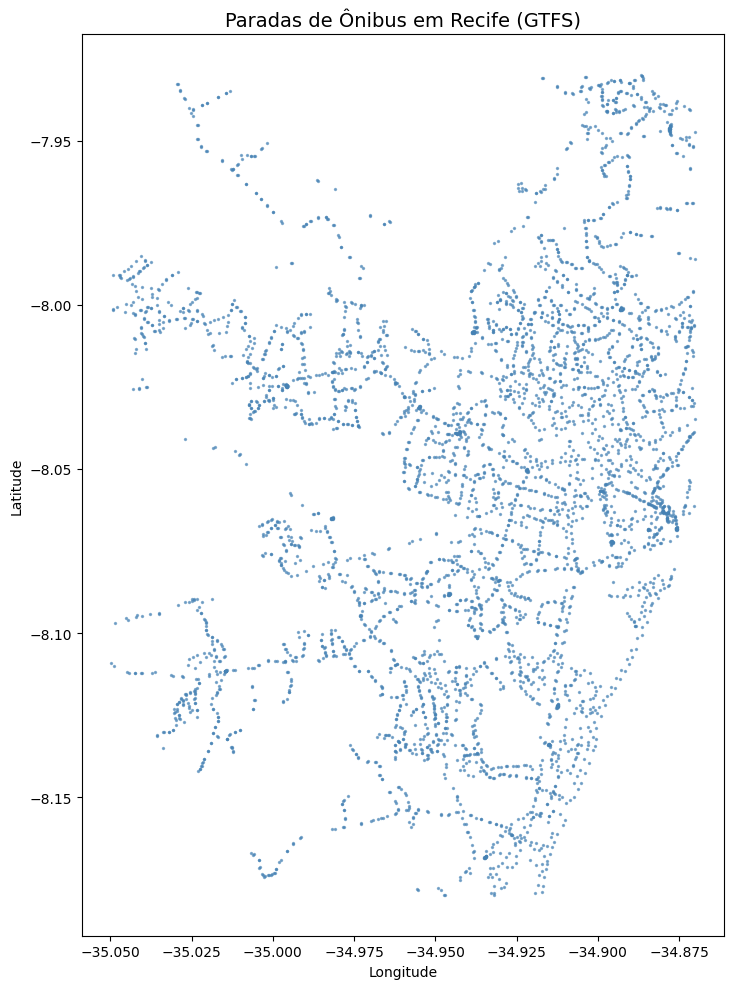

Total de paradas plotadas: 4748


In [39]:
# Plota as paradas no mapa
fig, ax = plt.subplots(figsize=(10, 10))
gdf_stops_recife.plot(ax=ax, markersize=2, color='steelblue', alpha=0.6)
ax.set_title('Paradas de Ônibus em Recife (GTFS)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()
print(f'Total de paradas plotadas: {len(gdf_stops_recife)}')

In [31]:
# Salva as paradas filtradas para uso no próximo notebook
OUT_STOPS = ROOT / 'data' / 'processed' / 'recife_paradas.geojson'
os.makedirs(OUT_STOPS.parent, exist_ok=True)
gdf_stops_recife.to_file(OUT_STOPS, driver='GeoJSON')
print(f'Paradas salvas em: {OUT_STOPS}')

Paradas salvas em: C:\Users\Adriana\IVU-Recife\data\processed\recife_paradas.geojson
